# Visualize Preprocessing: filter_and_reconstruct_coordinates_by_segment
Visualize the effect of filtering out large displacements and reconstructing the coordinates per segment.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.path.abspath('..'))

In [2]:
# Load sample data
treatment_dir = "TERBINAFINE- (control)"
sample = 'coordinates_highestspeed_20240827_10_1_with_time_speed.csv'

raw_sample_path = os.path.join('..', 'data', treatment_dir, sample)
preprocess_path = os.path.join('..', 'temp', treatment_dir, sample)

df = pd.read_csv(raw_sample_path)
df_cleaned = pd.read_csv(preprocess_path)

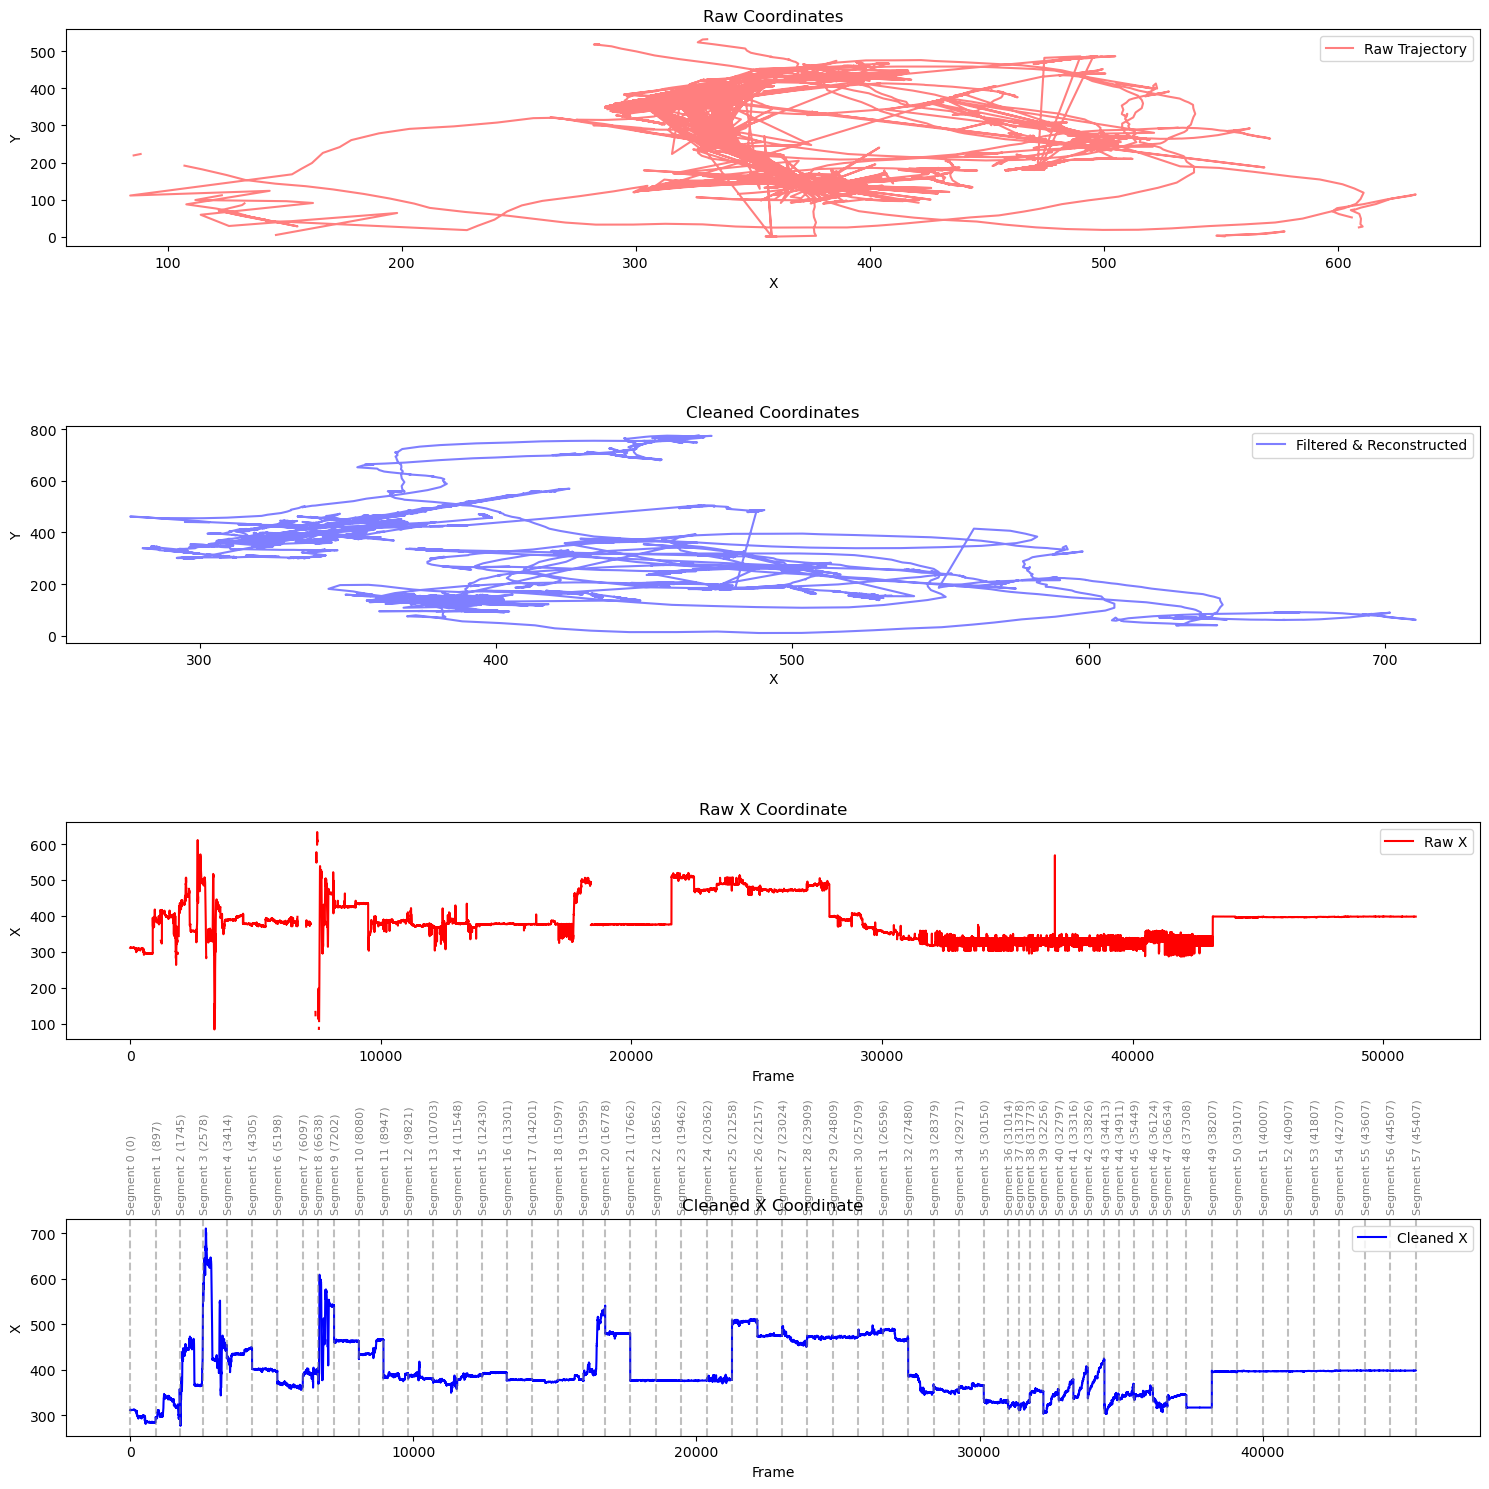

In [37]:
# Plotting
fig, axes = plt.subplots(4, 1, figsize=(15, 15))

# Raw data
axes[0].plot(df['X'], df['Y'], alpha=0.5, label='Raw Trajectory', color='red')
axes[0].set_title('Raw Coordinates')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()

# Cleaned data
axes[1].plot(df_cleaned['X'], df_cleaned['Y'], alpha=0.5, label='Filtered & Reconstructed', color='blue')
axes[1].set_title('Cleaned Coordinates')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()

# Only X on raw
axes[2].plot(df['X'], label='Raw X', color='red')
axes[2].set_title('Raw X Coordinate')
axes[2].set_xlabel('Frame')
axes[2].set_ylabel('X')
axes[2].legend()

# Only X on cleaned, visualize the segments with vertical lines
axes[3].plot(df_cleaned['X'], label='Cleaned X', color='blue')
axes[3].set_title('Cleaned X Coordinate')
axes[3].set_xlabel('Frame')
axes[3].set_ylabel('X')
for segment_id in df_cleaned['Segment'].unique():
    segment_start = df_cleaned[df_cleaned['Segment'] == segment_id].index.min()
    axes[3].axvline(x=segment_start, color='gray', linestyle='--', alpha=0.5)
    # write the segment number above the line
    axes[3].text(segment_start+250, axes[3].get_ylim()[1]+10, f'Segment {segment_id} ({segment_start})', rotation=90, verticalalignment='bottom', horizontalalignment='right', fontsize=8, color='gray')
axes[3].legend()

plt.tight_layout()
plt.show()